# Analyzing Global Black Money Transaction Patterns Involving Tax Havens: An Exploratory Data Analysis Approach

### Hacktiv8 Comprehensive Data Analytics Program — Final Project
**Kelompok 2**

Selvyana Natalia Purnomo - Data Analyst

Joshua Andika            - Data Analyst

Muhammad Rifqi Sahib     - Data Engineer

Kairenzo Vemil           - Data Engineer

**Batch 021**

---

### Attachment Link

1. Kaggle : https://www.kaggle.com/datasets/waqi786/global-black-money-transactions-dataset/

2. Google Slide : https://docs.google.com/presentation/d/1mN0ROV4yoUybHWk8D-qLpXti1wA14J5zuZlIFNjDlZI/edit?usp=sharing

3. Tableau : https://public.tableau.com/shared/GT9PZ8QMR?:display_count=n&:origin=viz_share_link

**DATA LOADING**

In [ ]:
# import library
import pandas as pd

In [ ]:
# Load the Dataset
data = pd.read_csv('Big_Black_Money_Dataset.csv')
data

,Transaction ID,Country,Amount (USD),Transaction Type,Date of Transaction,Person Involved,Industry,Destination Country,Reported by Authority,Source of Money,Money Laundering Risk Score,Shell Companies Involved,Financial Institution,Tax Haven Country
0,TX0000000001,Brazil,3.267530e+06,Offshore Transfer,2013-01-01 00:00:00,Person_1101,Construction,USA,True,Illegal,6,1,Bank_40,Singapore
1,TX0000000002,China,4.965767e+06,Stocks Transfer,2013-01-01 01:00:00,Person_7484,Luxury Goods,South Africa,False,Illegal,9,0,Bank_461,Bahamas
2,TX0000000003,UK,9.416750e+04,Stocks Transfer,2013-01-01 02:00:00,Person_3655,Construction,Switzerland,True,Illegal,1,3,Bank_387,Switzerland
3,TX0000000004,UAE,3.864201e+05,Cash Withdrawal,2013-01-01 03:00:00,Person_3226,Oil & Gas,Russia,False,Illegal,7,2,Bank_353,Panama
4,TX0000000005,South Africa,6.433784e+05,Cryptocurrency,2013-01-01 04:00:00,Person_7975,Real Estate,USA,True,Illegal,1,9,Bank_57,Luxembourg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,TX0000009996,Singapore,2.209229e+06,Offshore Transfer,2014-02-21 11:00:00,Person_6896,Real Estate,Brazil,False,Illegal,4,4,Bank_258,Luxembourg
9996,TX0000009997,UAE,4.800338e+06,Property Purchase,2014-02-21 12:00:00,Person_6348,Luxury Goods,Russia,False,Legal,10,2,Bank_449,Luxembourg
9997,TX0000009998,UK,4.891953e+05,Stocks Transfer,2014-02-21 13:00:00,Person_4171,Oil & Gas,Russia,False,Illegal,5,0,Bank_156,Cayman Islands
9998,TX0000009999,Brazil,2.233581e+06,Offshore Transfer,2014-02-21 14:00:00,Person_2799,Real Estate,Russia,True,Illegal,10,5,Bank_12,Singapore


In [ ]:
# Check Transaction ID length
data['Transaction ID'].str.len().value_counts()

Transaction ID
12    10000
Name: count, dtype: int64

In [ ]:
# Display Column Names to understand the structure of the dataset
data.columns


Index(['Transaction ID', 'Country', 'Amount (USD)', 'Transaction Type',
       'Date of Transaction', 'Person Involved', 'Industry',
       'Destination Country', 'Reported by Authority', 'Source of Money',
       'Money Laundering Risk Score', 'Shell Companies Involved',
       'Financial Institution', 'Tax Haven Country'],
      dtype='str')

In [ ]:
# Check Data Types and Missing Values
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Transaction ID               10000 non-null  str    
 1   Country                      10000 non-null  str    
 2   Amount (USD)                 10000 non-null  float64
 3   Transaction Type             10000 non-null  str    
 4   Date of Transaction          10000 non-null  str    
 5   Person Involved              10000 non-null  str    
 6   Industry                     10000 non-null  str    
 7   Destination Country          10000 non-null  str    
 8   Reported by Authority        10000 non-null  bool   
 9   Source of Money              10000 non-null  str    
 10  Money Laundering Risk Score  10000 non-null  int64  
 11  Shell Companies Involved     10000 non-null  int64  
 12  Financial Institution        10000 non-null  str    
 13  Tax Haven Country           

In [ ]:
data['Date of Transaction'] = pd.to_datetime(data['Date of Transaction'])
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Transaction ID               10000 non-null  str           
 1   Country                      10000 non-null  str           
 2   Amount (USD)                 10000 non-null  float64       
 3   Transaction Type             10000 non-null  str           
 4   Date of Transaction          10000 non-null  datetime64[us]
 5   Person Involved              10000 non-null  str           
 6   Industry                     10000 non-null  str           
 7   Destination Country          10000 non-null  str           
 8   Reported by Authority        10000 non-null  bool          
 9   Source of Money              10000 non-null  str           
 10  Money Laundering Risk Score  10000 non-null  int64         
 11  Shell Companies Involved     10000 non-null  int64   

In [ ]:
data['Transaction ID'] = data['Transaction ID'].astype('string')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Transaction ID               10000 non-null  string        
 1   Country                      10000 non-null  str           
 2   Amount (USD)                 10000 non-null  float64       
 3   Transaction Type             10000 non-null  str           
 4   Date of Transaction          10000 non-null  datetime64[us]
 5   Person Involved              10000 non-null  str           
 6   Industry                     10000 non-null  str           
 7   Destination Country          10000 non-null  str           
 8   Reported by Authority        10000 non-null  bool          
 9   Source of Money              10000 non-null  str           
 10  Money Laundering Risk Score  10000 non-null  int64         
 11  Shell Companies Involved     10000 non-null  int64   

In [ ]:
# Summary Statistics for Numercial Columns
data.describe()

,Amount (USD),Date of Transaction,Money Laundering Risk Score,Shell Companies Involved
count,1.000000e+04,10000,10000.000000,10000.000000
mean,2.501818e+06,2013-07-28 07:30:00,5.526400,4.469400
min,1.003180e+04,2013-01-01 00:00:00,1.000000,0.000000
25%,1.279005e+06,2013-04-15 03:45:00,3.000000,2.000000
50%,2.501310e+06,2013-07-28 07:30:00,6.000000,4.000000
75%,3.722416e+06,2013-11-09 11:15:00,8.000000,7.000000
max,4.999812e+06,2014-02-21 15:00:00,10.000000,9.000000
std,1.424364e+06,NaN,2.893603,2.879773


In [ ]:
# Check Duplicate Data
data.duplicated().sum()

np.int64(0)

In [ ]:
# Check for Missing Values
data.isnull().sum()

Transaction ID                 0
Country                        0
Amount (USD)                   0
Transaction Type               0
Date of Transaction            0
Person Involved                0
Industry                       0
Destination Country            0
Reported by Authority          0
Source of Money                0
Money Laundering Risk Score    0
Shell Companies Involved       0
Financial Institution          0
Tax Haven Country              0
dtype: int64

**ANALYSIS AND CALCULATION**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

**Question 1 (Descriptive Statistics)**

What are the distribution patterns of Risk Score, Shell Companies Involved, and Tax Haven Countries across transactions?


       Money Laundering Risk Score  Shell Companies Involved
count                     10000.00                  10000.00
mean                          5.53                      4.47
std                           2.89                      2.88
min                           1.00                      0.00
25%                           3.00                      2.00
50%                           6.00                      4.00
75%                           8.00                      7.00
max                          10.00                      9.00
Tax Haven Country
Panama            1743
Luxembourg        1681
Cayman Islands    1676
Singapore         1644
Bahamas           1628
Switzerland       1628
Name: count, dtype: int64


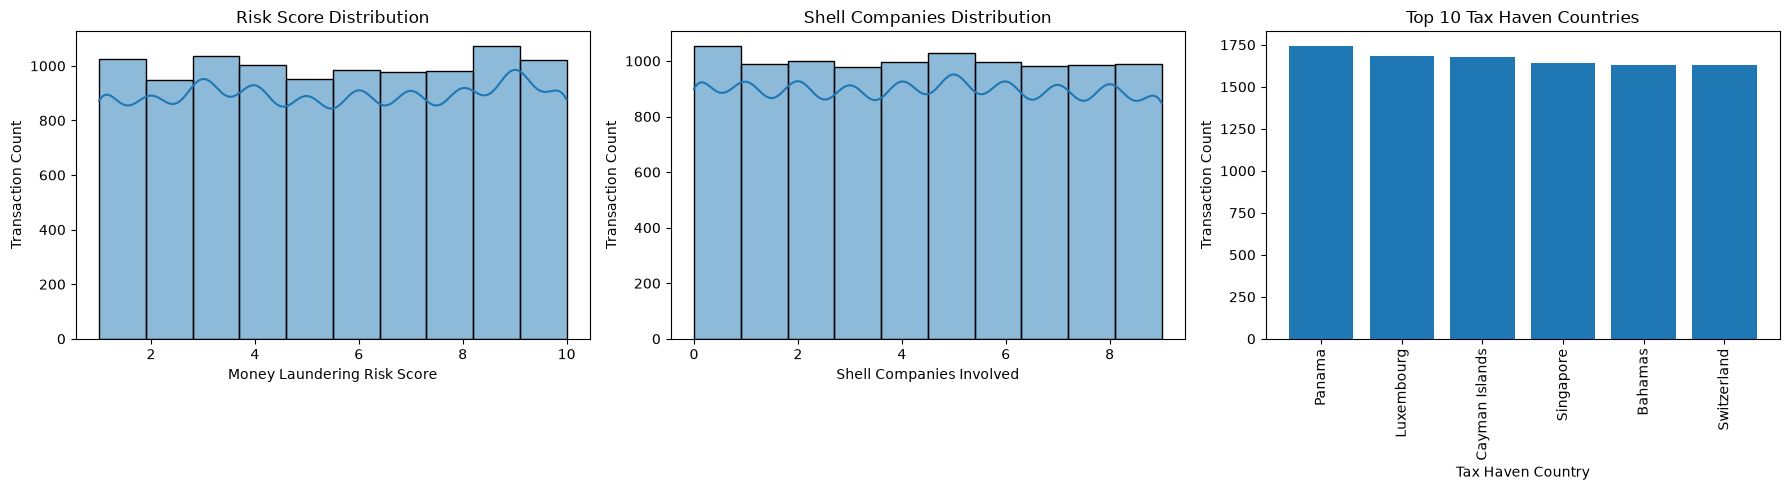

In [ ]:
# Descriptive Statistics
print(data[['Money Laundering Risk Score',
            'Shell Companies Involved']].describe().round(2))

print(data['Tax Haven Country'].value_counts())


# Visualization
fig, axes = plt.subplots(1,3, figsize=(18,5))


# 1. Money Laundering Risk Score Distribution
sns.histplot(data['Money Laundering Risk Score'], bins=10, kde=True, ax=axes[0])
axes[0].set_xlabel('Money Laundering Risk Score')
axes[0].set_ylabel('Transaction Count')
axes[0].set_title('Risk Score Distribution')


# 2. Shell Companies Involved Distribution
sns.histplot(data['Shell Companies Involved'], bins=10, kde=True, ax=axes[1])
axes[1].set_xlabel('Shell Companies Involved')
axes[1].set_ylabel('Transaction Count')
axes[1].set_title('Shell Companies Distribution')


# 3. Top 10 Tax Haven Countries
plot_data = data['Tax Haven Country'].value_counts().head(10)
bars = plt.bar(plot_data.index, plot_data.values)
axes[2].set_xlabel('Tax Haven Country')
axes[2].set_ylabel('Transaction Count')
axes[2].set_title('Top 10 Tax Haven Countries')
axes[2].tick_params(axis='x',rotation=90)

# Layout
plt.tight_layout()
plt.show()

The histograms above illustrate the distributions of Money Laundering Risk Score and Shell Companies Involved, along with transaction frequencies across the six Tax Haven Countries. The mean Money Laundering Risk Score is 5.53, with a median of 6 and a standard deviation of 2.89, across a score range of 1–10. The histogram shows a relatively even distribution across the score values, with no substantial concentration of transactions in either the low-risk or high-risk categories. Meanwhile, Shell Companies Involved ranges from 0 to 9, with a mean of 4.47, a median of 4, and a standard deviation of 2.88. Its histogram similarly indicates a relatively even distribution across the different numbers of shell companies, without a clearly dominant category. Regarding Tax Haven Countries, Panama records the highest transaction frequency with 1,743 transactions, followed by Luxembourg (1,681), the Cayman Islands (1,676), Singapore (1,644), the Bahamas (1,628), and Switzerland (1,628). The difference between the highest and lowest transaction counts is only 115 transactions, indicating relatively small variations in transaction frequency across the six jurisdictions, with no single country overwhelmingly dominating the distribution. Overall, the three variables exhibit relatively balanced distributions within their respective categories. These findings indicate that transactions in the dataset are spread across different money laundering risk scores, numbers of shell companies, and tax haven jurisdictions, without a particularly pronounced concentration in any one category. This descriptive overview provides a foundation for further investigation into the relationships between transaction characteristics and potential money laundering risks.

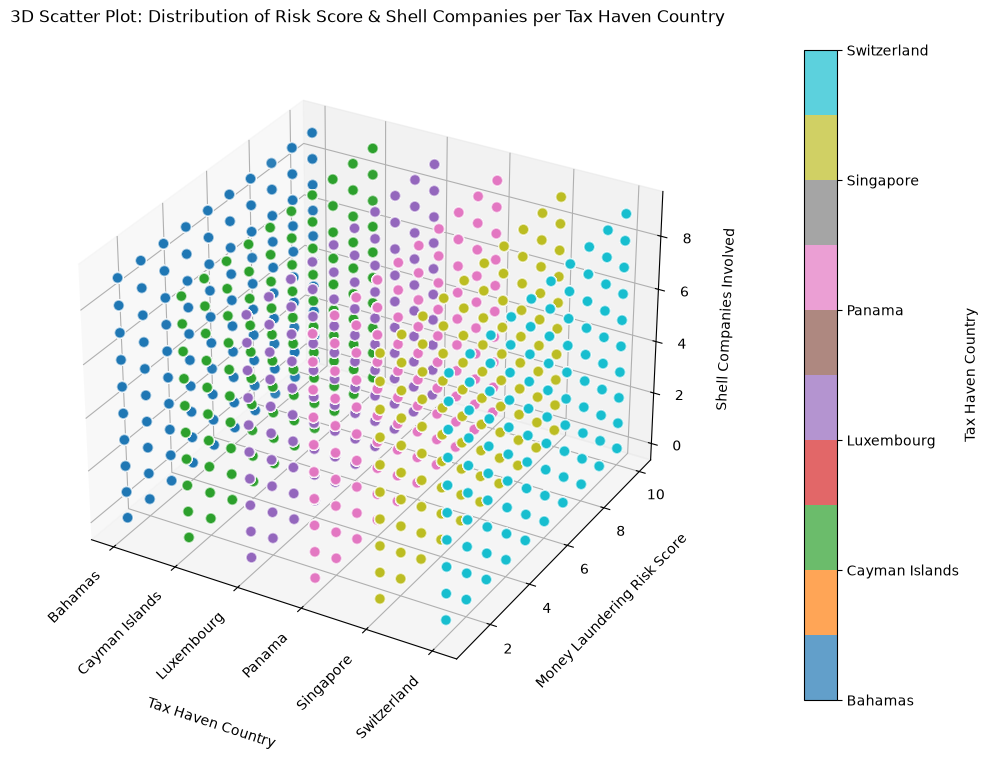

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Prepare data for 3D Scatter Plot
fig = plt.figure(figsize=(14,10))
ax = fig.add_subplot(111, projection='3d')

# Extract Columns for the Scatter Plot
tax_haven_categories = data['Tax Haven Country'].astype('category')

x = tax_haven_categories.cat.codes
y = data['Money Laundering Risk Score']
z = data['Shell Companies Involved']

# Color Based on Tax Haven Country
c = tax_haven_categories.cat.codes

# Create the 3D Scatter Plot
scatter = ax.scatter(
    x, y, z,
    c=c,
    cmap='tab10',
    alpha=0.7,
    edgecolors='w',
    s=60)

# Create Colorbar
cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Tax Haven Country')

tax_haven_names = tax_haven_categories.cat.categories

cbar.set_ticks(range(len(tax_haven_names)))
cbar.set_ticklabels(tax_haven_names)

# Set X-axis ticks to show actual Tax Haven Country names
ax.set_xticks(range(len(tax_haven_names)))
ax.set_xticklabels(tax_haven_names, rotation=45, ha='right')

# Set labels and title
ax.set_xlabel('Tax Haven Country', labelpad=43)
ax.set_ylabel('Money Laundering Risk Score', labelpad=15)
ax.set_zlabel('Shell Companies Involved', labelpad=10)

ax.set_title('3D Scatter Plot: Distribution of Risk Score & Shell Companies per Tax Haven Country',pad=20)

# Add more space at the bottom
plt.subplots_adjust(left=0.05,right=0.85,bottom=0.25,top=0.90)
plt.show()

The 3D Scatter Plot above depicts the distribution of Money Laundering Risk Scores and Shell Companies Involved in various Tax Haven Countries. This visualization examines the distribution of money laundering risk scores and the number of shell businesses participating in transactions among tax haven countries. The X-axis represents the tax haven nation categories, the Y-axis shows the Money Laundering Risk Score, which ranges from 1 to 10, and the Z-axis shows the number of Shell Companies Involved, which ranges from 0 to 9. Each point represents a single transaction mapped over these three variables, with different colors indicating tax haven nation categories. The visualization shows that transactions are dispersed over various combinations of risk scores and shell company counts in each country, with no evident patterns distinguishing between country groups. Transactions with low and high risk scores, as well as varying quantities of shell corporations, have been recorded in several tax haven countries. As a result, no particularly prominent concentration is seen for any given combination of variables. Overall, this image shows how Money Laundering Risk Scores and the number of Shell Companies Involved differ between the tax haven nation categories contained in the dataset.

**Question 2 (Descriptive Statistics)**

How does money laundering risk vary across industries?



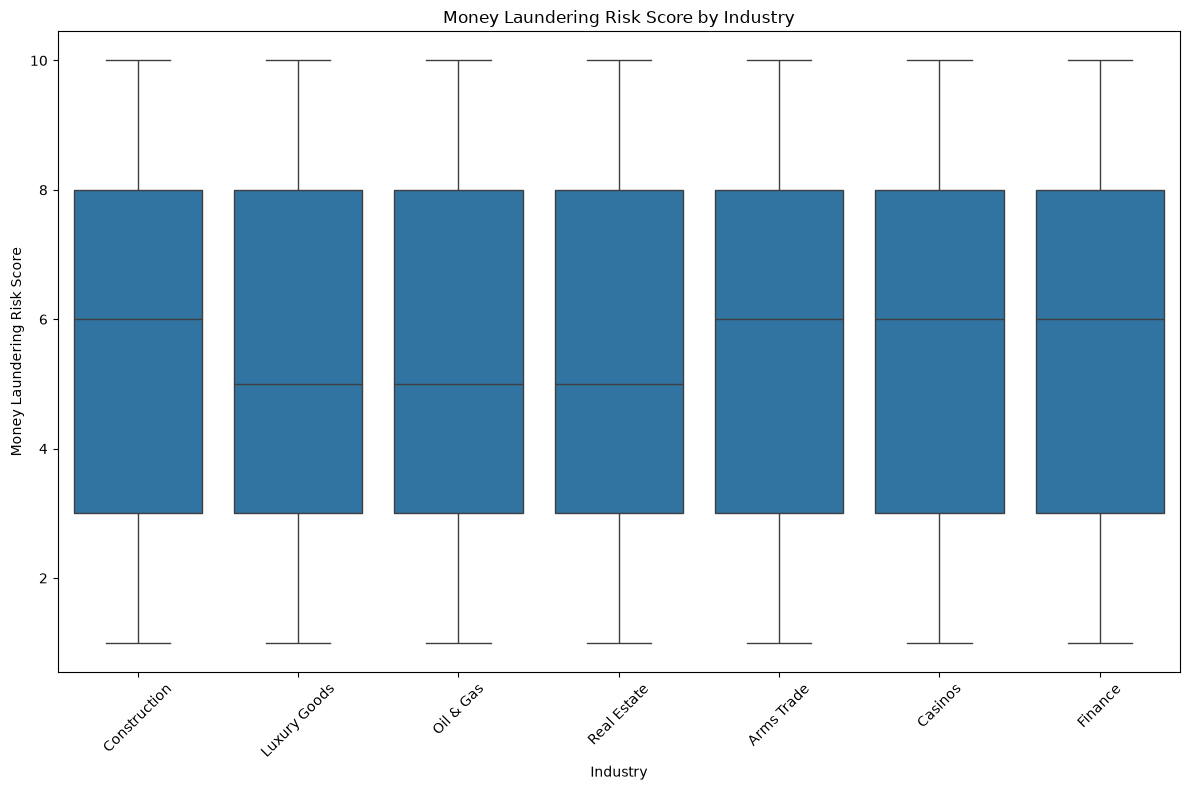

Industry  Arms Trade  Casinos  Construction  Finance  Luxury Goods  Oil & Gas  \
count        1414.00  1377.00       1460.00  1475.00       1459.00    1372.00   
mean            5.57     5.56          5.58     5.71          5.37       5.43   
std             2.92     2.91          2.90     2.89          2.86       2.86   
min             1.00     1.00          1.00     1.00          1.00       1.00   
25%             3.00     3.00          3.00     3.00          3.00       3.00   
50%             6.00     6.00          6.00     6.00          5.00       5.00   
75%             8.00     8.00          8.00     8.00          8.00       8.00   
max            10.00    10.00         10.00    10.00         10.00      10.00   

Industry  Real Estate  
count         1443.00  
mean             5.46  
std              2.91  
min              1.00  
25%              3.00  
50%              5.00  
75%              8.00  
max             10.00  


In [ ]:
# Boxplot of money laundering risk score by industry
plt.figure(figsize=(12, 8))
sns.boxplot(data=data, x='Industry', y='Money Laundering Risk Score')
plt.title('Money Laundering Risk Score by Industry')
plt.xlabel('Industry')
plt.ylabel('Money Laundering Risk Score')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Descriptive statistics of Risk Score per Industry
industry_stats = data.groupby('Industry')['Money Laundering Risk Score'].describe().T.round(2)
print(industry_stats)

The box plot above illustrates the distribution of Money Laundering Risk Scores across seven industry sectors: Arms Trade, Casinos, Construction, Finance, Luxury Goods, Oil & Gas, and Real Estate. According to the descriptive statistics, Finance records the highest average Money Laundering Risk Score at 5.71, followed by Construction (5.58), Arms Trade (5.57), and Casinos (5.56). Meanwhile, Luxury Goods has the lowest average score at 5.37, followed by Oil & Gas (5.43) and Real Estate (5.46). Despite these differences, the gap between the highest and lowest mean scores is only 0.34 points on a 1–10 scale, indicating relatively minor differences in average risk scores across industries. The median scores range from 5 to 6, with Finance, Construction, Arms Trade, and Casinos having a median of 6, while Luxury Goods, Oil & Gas, and Real Estate have a median of 5. All seven sectors share the same interquartile range, with the first quartile (Q1) at 3 and the third quartile (Q3) at 8. Additionally, all sectors have a minimum score of 1 and a maximum score of 10, while standard deviations range from 2.86 to 2.92, indicating similar levels of variability. Overall, the box plot and descriptive statistics suggest that Money Laundering Risk Scores exhibit relatively similar distributions across all seven industry sectors, with no industry showing a notably different spread or a substantially higher or lower average risk score than the others.

**Question 3 (Inferential Statistics)**

Statistical Validation: Does Source of Money Significantly Affect Risk Score?

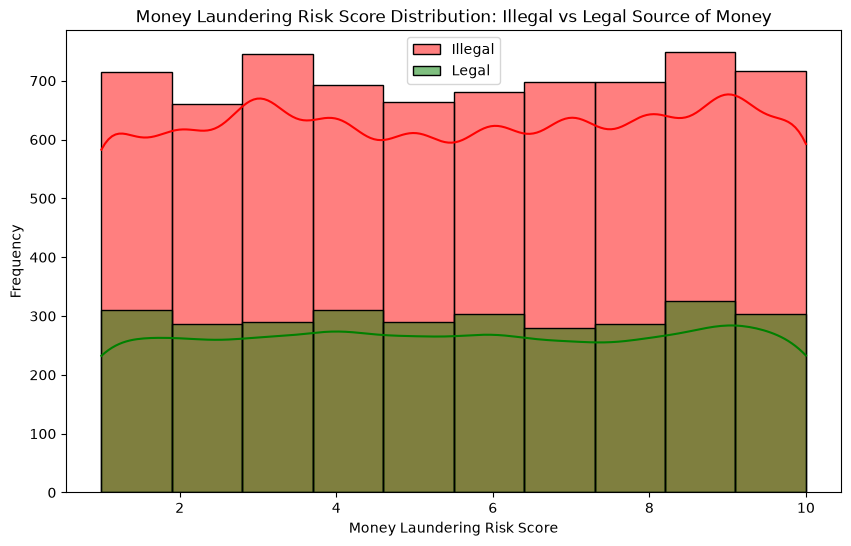

T-statistic:0.2058, P-value: 0.8370
Mean Illegal: 5.53, Mean Legal: 5.52


In [ ]:
from scipy.stats import ttest_ind

#  Histogram overlay
plt.figure(figsize=(10,6))

sns.histplot(data[data['Source of Money']=='Illegal']['Money Laundering Risk Score'],
             bins=10, kde=True, color='red', alpha=0.5, label='Illegal')

sns.histplot(data[data['Source of Money']=='Legal']['Money Laundering Risk Score'],
             bins=10, kde=True, color='green', alpha=0.5, label='Legal')

plt.title('Money Laundering Risk Score Distribution: Illegal vs Legal Source of Money')
plt.xlabel('Money Laundering Risk Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Statistical Test: Independent T-Test
illegal = data[data['Source of Money'] == 'Illegal']['Money Laundering Risk Score']
legal = data[data['Source of Money'] == 'Legal']['Money Laundering Risk Score']

t_stat, p_value = ttest_ind(illegal, legal, equal_var=False)

print(f"T-statistic:{t_stat:.4f}, P-value: {p_value:.4f}")
print(f"Mean Illegal: {illegal.mean():.2f}, Mean Legal: {legal.mean():.2f}")


The histogram above illustrates the distribution of Money Laundering Risk Scores based on illegal and legal sources of money. This analysis aims to compare the distribution of risk scores between the two funding source groups. According to the descriptive statistics, transactions involving illegal sources of money have an average risk score of 5.53, while transactions involving legal sources have an average score of 5.52. The minimal difference of 0.01 points indicates that the average Money Laundering Risk Scores of the two groups are very similar. Furthermore, the histogram shows substantial overlap between the two distributions, with both groups exhibiting risk scores ranging from 1 to 10 and no noticeable differences in their overall distribution patterns. To statistically examine the difference in average risk scores, an Independent Two-Sample T-Test was conducted, resulting in a T-statistic of 0.2058 and a P-value of 0.8369. At a 5% significance level (α = 0.05), the P-value exceeds the significance threshold, indicating insufficient statistical evidence to reject the null hypothesis (H₀). Therefore, there is no statistically significant difference in the average Money Laundering Risk Score between transactions involving illegal and legal sources of money in the analyzed dataset. Overall, these findings suggest that both funding source groups exhibit similar average risk scores and distribution patterns, indicating that the source of money does not show a statistically significant difference in the average Money Laundering Risk Score within this sample.

**Question 4 (Inferential Statistics)**

Statistical Validation: Is Transaction Amount Significantly Different Between Reported and Non-Reported Transactions?

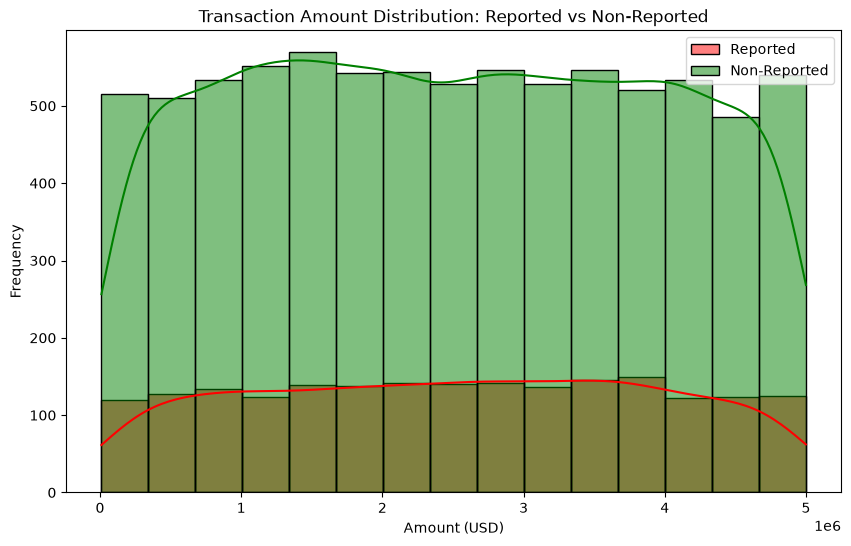

T-statistic:0.5213, P-value: 0.6021
Mean Reported: 2,516,646.39, Mean Non-Reported: 2,498,098.89


In [ ]:
from scipy.stats import ttest_ind

#  Histogram overlay
plt.figure(figsize=(10,6))

sns.histplot(data[data['Reported by Authority']==True]['Amount (USD)'],
             bins=15, kde=True, color='red', alpha=0.5, label='Reported')

sns.histplot(data[data['Reported by Authority']==False]['Amount (USD)'],
             bins=15, kde=True, color='green', alpha=0.5, label='Non-Reported')

plt.title('Transaction Amount Distribution: Reported vs Non-Reported')
plt.xlabel('Amount (USD)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Statistical Test: Independent T-Test
reported = data[data['Reported by Authority'] ==True]['Amount (USD)']
non_reported = data[data['Reported by Authority'] ==False]['Amount (USD)']

t_stat, p_value = ttest_ind(reported, non_reported)

print(f"T-statistic:{t_stat:.4f}, P-value: {p_value:.4f}")
print(f"Mean Reported: {reported.mean():,.2f}, Mean Non-Reported: {non_reported.mean():,.2f}")

The histogram above illustrates the distribution of Transaction Amount (USD) based on transaction reporting status (Reported and Non-Reported). This analysis aims to determine whether there is a significant difference in transaction amounts between the two groups, which may provide insights into financial flows potentially associated with global black market activities. According to the descriptive statistics, reported transactions have an average transaction amount of USD 2,516,646.39, while non-reported transactions have an average of USD 2,498,098.89. Although reported transactions have a slightly higher mean, the difference is only USD 18,547.50. The histogram also shows overlapping distributions between the two groups, with no substantial visual differences in their transaction amount patterns. To statistically examine this difference, an Independent Two-Sample T-Test was conducted, yielding a T-statistic of 0.5213 and a P-value of 0.6021. At a 5% significance level (α = 0.05), the P-value exceeds the significance threshold, indicating insufficient statistical evidence to reject the null hypothesis (H₀). Therefore, no statistically significant difference was found in the average transaction amounts between reported and non-reported transactions in the analyzed dataset. In the context of global black market research, these findings suggest that transaction reporting status is not associated with a statistically significant difference in average transaction amounts within this sample. Further analysis incorporating additional financial risk indicators may provide a more comprehensive understanding of transaction characteristics potentially associated with money laundering and cross-border illicit economic activities.

**Question 5 (Inferential Statistics)**

Statistical Validation: Are there specific money laundering routes (origin → destination → tax haven) that occur more frequently than others?

In [ ]:
route_counts = data.groupby(['Country', 'Destination Country', 'Tax Haven Country']).size().reset_index(name='Count')
route_counts = route_counts.sort_values('Count', ascending=False)
print(route_counts.head(15))
print("\nJumlah kombinasi rute unik:", len(route_counts))
print("Count minimum:", route_counts['Count'].min())
print("Count maximum:", route_counts['Count'].max())

          Country Destination Country Tax Haven Country  Count
259     Singapore              Russia    Cayman Islands     32
513            UK        South Africa            Panama     29
293     Singapore                  UK       Switzerland     28
494            UK               India        Luxembourg     27
453           UAE        South Africa            Panama     27
132         India               India           Bahamas     27
344  South Africa                 UAE        Luxembourg     27
549           USA               China            Panama     27
375   Switzerland               India            Panama     26
443           UAE              Russia       Switzerland     26
147         India           Singapore            Panama     26
560           USA              Russia        Luxembourg     26
237        Russia                 USA            Panama     25
39         Brazil         Switzerland            Panama     25
269     Singapore           Singapore       Switzerland

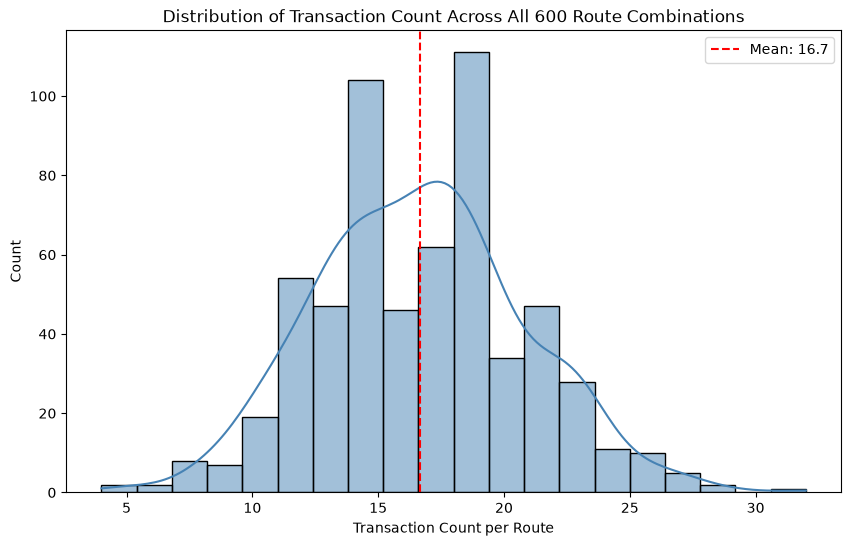

count    600.00
mean      16.67
std        4.17
min        4.00
25%       14.00
50%       17.00
75%       19.00
max       32.00
Name: Count, dtype: float64


In [ ]:
# Histogram and Descriptive Statistics
plt.figure(figsize=(10, 6))
sns.histplot(route_counts['Count'], bins=20, kde=True, color='steelblue')
plt.axvline(route_counts['Count'].mean(), color='red', linestyle='--', label=f"Mean: {route_counts['Count'].mean():.1f}")
plt.title('Distribution of Transaction Count Across All 600 Route Combinations')
plt.xlabel('Transaction Count per Route')
plt.legend()
plt.show()

# Descriptive statistics of transaction count per route
print(route_counts['Count'].describe().round(2))

/var/folders/j7/nf9y30zd4s55qr4g07w6rhc80000gn/T/ipykernel_16523/1907736464.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=route_counts.head(15), y='Route', x='Count', palette='rocket')


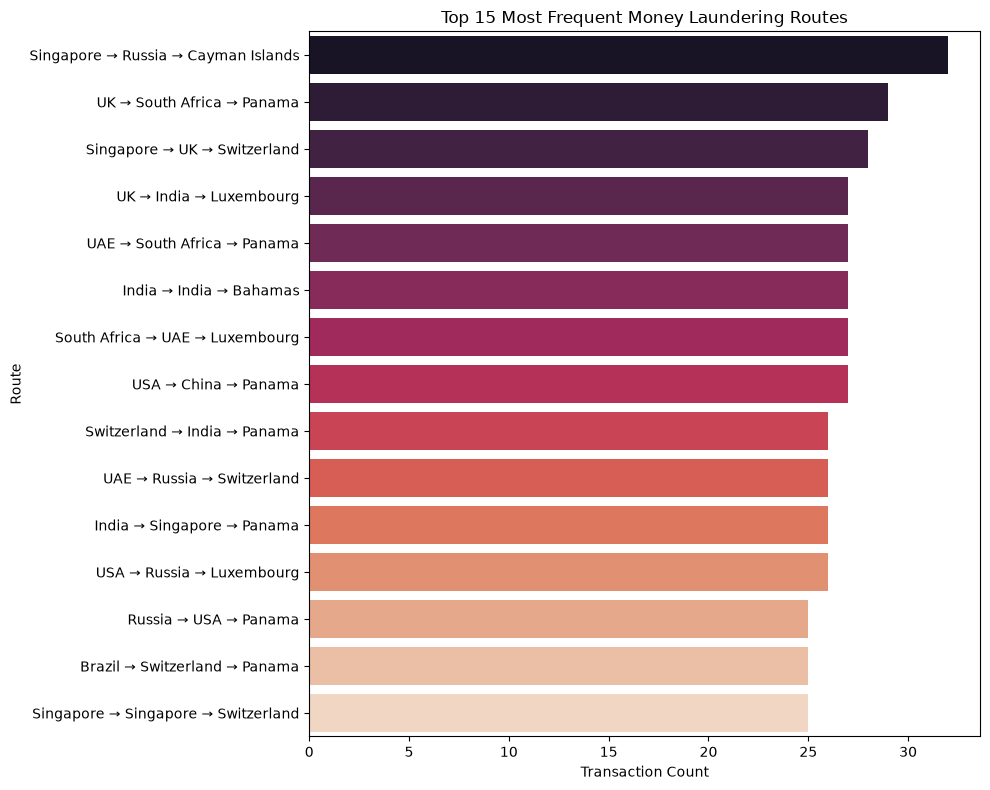

In [ ]:
# Aggregate Transactions Counts by Route
route_counts = data.groupby(['Country', 'Destination Country', 'Tax Haven Country']).size().reset_index(name='Count')

# Sort Routes by Transaction Frequency
route_counts = route_counts.sort_values('Count', ascending=False)

# Create Route Labels
route_counts['Route'] = route_counts['Country'] + ' → ' + route_counts['Destination Country'] + ' → ' + route_counts['Tax Haven Country']

# Visualize Top 15 Most Frequent Routes
plt.figure(figsize=(10, 8))
sns.barplot(data=route_counts.head(15), y='Route', x='Count', palette='rocket')
plt.title('Top 15 Most Frequent Money Laundering Routes')
plt.xlabel('Transaction Count')
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import chisquare

# Observed: jumlah transaksi aktual per rute (dari route_counts yang sudah dibuat)
observed = route_counts['Count'].values

# Expected: kalau benar-benar merata, tiap rute harusnya dapat porsi yang sama
expected = [observed.sum() / len(observed)] * len(observed)

chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {len(observed) - 1}")
print(f"Expected count per route: {expected[0]:.2f}")

Chi-Square Statistic: 624.3200
P-value: 0.2294
Degrees of Freedom: 599
Expected count per route: 16.67


### Inferential Statistics: Chi-Square Goodness of Fit Test

This analysis examines whether transaction counts are uniformly distributed across the 600 observed route combinations, based on origin country, destination country, and tax haven country. The Chi-Square Goodness of Fit Test is used to compare the observed transaction frequencies with the expected frequencies under a uniform distribution.

* **H₀:** Transaction counts are uniformly distributed across the 600 route combinations.
* **H₁:** Transaction counts are not uniformly distributed across the 600 route combinations.
* **Significance Level (α):** 0.05


In [ ]:
print("Jumlah unique Country:", data['Country'].nunique())
print("Jumlah unique Destination Country:", data['Destination Country'].nunique())
print("Jumlah unique Tax Haven Country:", data['Tax Haven Country'].nunique())

print("\nList Destination Country:", sorted(data['Destination Country'].unique()))

Jumlah unique Country: 10
Jumlah unique Destination Country: 10
Jumlah unique Tax Haven Country: 6

List Destination Country: ['Brazil', 'China', 'India', 'Russia', 'Singapore', 'South Africa', 'Switzerland', 'UAE', 'UK', 'USA']


This analysis aims to identify transaction frequency patterns across money laundering routes, defined by combinations of origin country (Country), destination country (Destination Country), and tax haven country. The dataset was grouped by these three variables, resulting in 600 unique route combinations, with transaction counts ranging from 4 to 32 per route. The routes were then sorted in descending order of transaction frequency to identify the 15 most frequently observed routes, which were visualized using a bar chart. Singapore → Russia → Cayman Islands recorded the highest transaction frequency, with 32 transactions, followed by UK → South Africa → Panama with 29 transactions, and Singapore → UK → Switzerland with 28 transactions. Panama appeared in 6 of the top 15 routes, suggesting that it is a frequently observed tax haven destination within this subset. Additionally, a histogram with a Kernel Density Estimation (KDE) curve and a mean reference line was generated to examine the distribution of transaction counts across all 600 route combinations. The average transaction count was 16.7 per route. To statistically evaluate whether transaction counts differed significantly from a uniform distribution, a Chi-Square Goodness of Fit Test was conducted. The null hypothesis (H₀) stated that transaction counts were uniformly distributed across the 600 route combinations, while the alternative hypothesis (H₁) stated that the distribution was not uniform. The test produced a Chi-Square Statistic of 624.32, a P-value of 0.2294, and 599 degrees of freedom, with an expected frequency of approximately 16.67 transactions per route under the uniform distribution assumption. At a 5% significance level (α = 0.05), the P-value exceeds the significance threshold, indicating insufficient statistical evidence to reject the null hypothesis. Therefore, the test did not detect a statistically significant deviation from a uniform distribution across the 600 route combinations. However, this does not mean that all routes have exactly the same transaction frequency, as the observed counts still vary across routes. Overall, although certain routes appear more frequently in the descriptive analysis, the inferential test does not provide sufficient evidence to conclude that transaction frequencies significantly deviate from a uniform distribution across the observed route combinations.